In [3]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 798.5 kB/s eta 0:07:20
   ---------------------------------------- 1.0/351.2 MB 1.4 MB/s eta 0:04:09
   ---------------------------------------- 1.8/351.2 MB 1.9 MB/s eta 0:03:06
   ---------------------------------------- 2.4/351.2 MB 2.1 MB/s eta 0:02:50
   ---------------------------------------- 2.9/351.2 MB 2.1 MB/s eta 0:02:47
   ---------------------------------------- 3.4/351.2 MB 2.2 MB/s eta 0:02:41
   ---------------------------------------- 3.9/351.2 MB 2.2 MB/s eta 0:02:36
    --------------------------------------- 4.7/351.2 MB 2.4 MB/s eta 0:02:28
    --------------------------------------- 5.5/351.2 MB 2.5 MB/s eta 0:02:20
    -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
TRAIN_DIR = r"C:\Users\vigne\Downloads\PlantVillage\Train"
VAL_DIR = r"C:\Users\vigne\Downloads\PlantVillage\Val"

print("Training folder:", TRAIN_DIR)
print("Validation folder:", VAL_DIR)

Training folder: C:\Users\vigne\Downloads\PlantVillage\Train
Validation folder: C:\Users\vigne\Downloads\PlantVillage\Val


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 43445 files belonging to 38 classes.


In [6]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10861 files belonging to 38 classes.


In [8]:
class_names = train_dataset.class_names

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

In [10]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("MobileNetV2 loaded.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step
MobileNetV2 loaded.


In [11]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

print("Model created.")

Model created.


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 38)                  │          48,678 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5
)

Epoch 1/5


C:\Users\vigne\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1016s 742ms/step - accuracy: 0.8787 - loss: 0.4465 - val_accuracy: 0.9413 - val_loss: 0.1960
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 991s 730ms/step - accuracy: 0.9444 - loss: 0.1807 - val_accuracy: 0.9565 - val_loss: 0.1438
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 989s 728ms/step - accuracy: 0.9547 - loss: 0.1439 - val_accuracy: 0.9579 - val_loss: 0.1346
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 974s 717ms/step - accuracy: 0.9607 - loss: 0.1214 - val_accuracy: 0.9602 - val_loss: 0.1286
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 979s 721ms/step - accuracy: 0.9618 - loss: 0.1138 - val_accuracy: 0.9594 - val_loss: 0.1239


In [14]:
val_loss, val_accuracy = model.evaluate(val_dataset)

print("Validation Loss:", val_loss)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 199s 584ms/step - accuracy: 0.9594 - loss: 0.1239
Validation Loss: 0.12390806525945663
Validation Accuracy: 95.94%


In [15]:
model.save("plant_disease_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [16]:
import os

print(os.path.abspath("plant_disease_model.keras"))

C:\Users\vigne\Hackathon - 404 Impact\plant_disease_model.keras


In [17]:
loaded_model = tf.keras.models.load_model(
    r"C:\Users\vigne\Hackathon - 404 Impact\plant_disease_model.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


In [19]:
def predict_image(image_path):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    predictions = loaded_model.predict(image_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    print("Prediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"{predicted_class}\nConfidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

Exact image being tested:
C:\Users\vigne\Downloads\PlantVillage\Val\Tomato___Early_blight\ca7035fa-f55d-49c7-9d89-3d513c8e35b1___RS_Erly.B 7556.JPG

Prediction: Tomato___Early_blight
Confidence: 50.64%


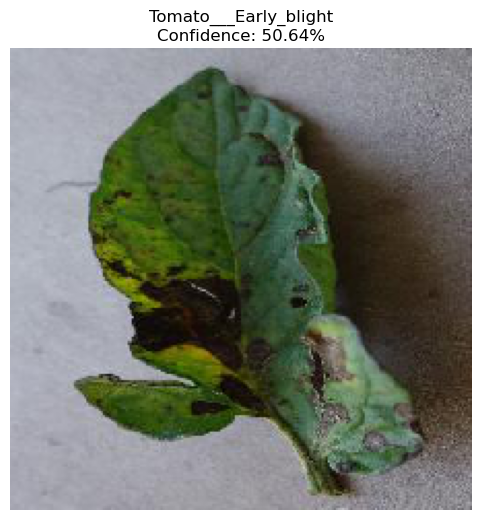

In [23]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

folder = r"C:\Users\vigne\Downloads\PlantVillage\Val\Tomato___Early_blight"

image_id = "ca7035fa-f55d-49c7-9d89-3d513c8e35b1___RS_Erly.B 7556"

# Find the exact file
matches = [
    f for f in os.listdir(folder)
    if image_id in f
]

if len(matches) == 0:
    print("Image not found.")
else:
    image_path = os.path.join(folder, matches[0])

    print("Exact image being tested:")
    print(image_path)

    # Load image
    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    # Convert to array
    image_array = tf.keras.utils.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)

    # Predict
    predictions = loaded_model.predict(image_array, verbose=0)

    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    print("\nPrediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

    # Display the exact image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(
        f"{predicted_class}\nConfidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()